In [1]:
from pathlib import Path
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import pandas as pd
import json
from tqdm import tqdm

In [2]:
def iter_video_frames(path, rgb=True):
    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {path}")

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            timestamp_ms = cap.get(cv2.CAP_PROP_POS_MSEC)

            if rgb:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            yield frame, timestamp_ms / 1000  # seconds

    finally:
        cap.release()
import cv2

import cv2

def read_selected_frames(path, frame_indices, rgb=True):
    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {path}")

    frames = []
    timestamps = []

    try:
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

            ok, frame = cap.read()
            if not ok:
                continue

            if rgb:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frames.append(frame)
            timestamps.append(cap.get(cv2.CAP_PROP_POS_MSEC) / 1000)

    finally:
        cap.release()

    return frames, timestamps


def get_edge(flame):
    fil = [[-1,-1,-1],
           [-1, 8,-1],
           [-1,-1,-1]]

    return (ndi.convolve(flame.astype(int), fil, mode='constant') > 1)  

def pixels_on_line(mask, bot_line, L_line, span):
    """
    Return min and max j idx of pixels that cyan lines pass through
    """

    # cyan line endpoints
    j0, j1 = span
    i0 = bot_line[0] - L_line
    i1 = bot_line[1] - L_line

    n = int(max(abs(i1 - i0), abs(j1 - j0))) + 1

    js = np.round(np.linspace(j0, j1, n)).astype(int)
    is_ = np.round(np.linspace(i0, i1, n)).astype(int)

    # keep only pixels inside image bounds
    valid = (
        (is_ >= 0) & (is_ < mask.shape[0]) &
        (js >= 0) & (js < mask.shape[1])
    )

    is_ = is_[valid]
    js = js[valid]

    # remove duplicate pixels from rounding
    coords = np.unique(np.column_stack([is_, js]), axis=0)
    is_, js = coords[:, 0], coords[:, 1]

    # non-zero mask pixels that the line passes through
    hit = mask[is_, js] != 0

    hit_is = is_[hit]
    hit_js = js[hit]

    min_idx = np.argmin(hit_js)
    max_idx = np.argmax(hit_js)

    return hit_js[min_idx], hit_js[max_idx]

In [3]:
path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders')
paths = sorted(list(path.glob('**/*.MOV')))
paths = [x for x in paths if 'V2_2.MOV' not in x.name] # get rid of V2_2 cos has loose top platen
V_paths = [x for x in paths if 'Elastico50V' in x.parent.name]
H_paths = [x for x in paths if 'Elastico50H' in x.parent.name]

In [4]:
paths

[PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/20260112/Elastico50V1.is_comp_Exports/V1_1.MOV'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/20260112/Elastico50V1.is_comp_Exports/V1_2.MOV'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/20260112/Elastico50V1.is_comp_Exports/V1_3.MOV'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/20260112/Elastico50V2.is_comp_Exports/V2_1.MOV'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/20260112/Elastico50V2.is_comp_Exports/V2_3.MOV'),
 PosixPath('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/ElasticoCylinders/202601

# Find POC
- Get frames and timestamps of frames that cover point of contact between top platen and specimen
- Identify frame where contact occurs

In [17]:
# get first frame for image crop bounds

path_idx = 9
vid_path = paths[path_idx]
vid_name = vid_path.with_suffix('').name
# SAVE POC FRAMES # - to hard to find the frame of first contact, even within 1 s
save_dir = vid_path.parent / f'POC/{vid_name}'
save_dir.mkdir(exist_ok=True, parents=True)

f_idx = 0
frame, t = read_selected_frames(vid_path, [f_idx])

H1_1


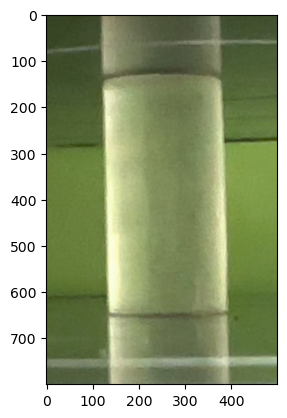

In [18]:
print(vid_name)
# crop images around specimen
i1 = 600 
i2 = i1 + 800
j1 = 1925
j2 = j1 + 500
#i1, i2 = (700, 1300)
#j1, j2 = (1800, 2450)
f = frame[0][i1:i2, j1:j2, :]

fig, ax = plt.subplots()
ax.imshow(f)
plt.show()

In [24]:
# identify time of contact from video to within 6s (0.5%)
tocs = {
    'V1_1': 28,
    'V1_2': 28,
    'V1_3': 27,
    'V2_1': 64,
    'V2_3': 32,
    'V2_4': 28,
    'V3_1': 28,
    'V3_2': 29,
    'V3_3': 27, 
    'H1_1': 29, 
    'H1_2': 32,
    'H1_3': 42,
    'H2_1': 34,
    'H2_2': 35,
    'H2_3': 40,
    'H3_1': 33,
    'H3_2': 33,
    'H3_3': 24
}

### Get frames every 0.2 mm up to 1 mm (5%)

In [ ]:
print(vid_path.name)

toc = tocs[vid_name]

fps = 30  # fps
strain_rate = 0.05 # mm / min

total_time = 48 # s (48s == 4% strain (identified contact within 1% strain so strain range is within 0->5%))
t_before, t_after = toc, toc + (strain_rate/60)*total_time # s (time of contact -> 1 mm )
f_before, f_after = t_before*fps, t_after*fps # frame idx
interval = 3 # s (0.025mm jumps)
f_interval = interval * fps # frames per jump
frame_ids = np.arange(f_before, f_after+1, f_interval)
frames, ts = read_selected_frames(vid_path, frame_ids)
frames = [frame[i1:i2, j1:j2, :] for frame in frames]

H1_1.MOV


### Choose threshold values for first and last frame and refine top/bottom line locations
- Settings top/bottom lines only affects cyan line placements for diamter measurements, so not super important.

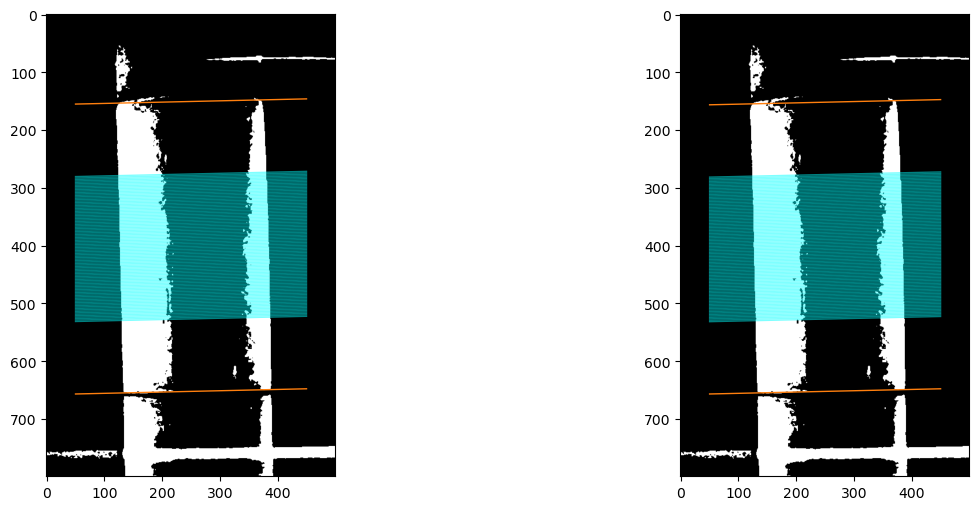

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

threshold = 100
bot_line = (657, 648)
span = (50, 450)
Lp0 = 502 # pixels
nlines = 101

for i, ax_i in enumerate(ax):
    #ax_i.imshow(frames[-i], cmap='gray')
    ax_i.imshow(np.where(frames[-i][:, :, 2]<threshold, 0, 1), cmap='gray')

    Lp = Lp0 - (i * Lp0 * (strain_rate/60)*interval) 
    top_line = (bot_line[0]-Lp, bot_line[1]-Lp)

    # plot lines that will be used for measurements
    lines_start = Lp / 4 # 5 mm (so central 10 mm)
    lines_gap = (Lp/2) / (nlines-1)


    ax_i.plot(span, top_line, linewidth=1, alpha=1, color='C1')
    ax_i.plot(span, bot_line, linewidth=1, alpha=1, color='C1')
    for k in range(nlines):
        L_line = lines_start + lines_gap * k
        line = (bot_line[0]-L_line, bot_line[1]-L_line)
        ax_i.plot(span, line, linewidth=1, color='cyan', alpha=0.5)

plt.show()

In [ ]:
# save info
info = {
    'fps': fps,
    'strain_rate': strain_rate,
    'toc': toc,
    'i1': i1,
    'i2': i2,
    'j1': j1,
    'j2': j2,
    't_before': t_before,
    't_after': t_after,
    'interval': interval,
    'total_time':total_time,
    'threshold': threshold,
    'span': span,
    'bot_line': bot_line,
    'Lp0': Lp0,
    'nlines': nlines,
}

with open(save_dir.parent / f'{vid_name}_info.json', 'w') as f:
    json.dump(info, f, indent=2)

In [117]:
results = []
for i, (f, t) in enumerate(zip(frames, ts)):
    frame_id = (i*f_interval)+f_before
    mask = np.where(f[:, :, 2]<threshold, 0, 1)

    Lp = Lp0 - (i * Lp0 * 0.01) # 1% strain jumps
    top_line = (bot_line[0]-Lp, bot_line[1]-Lp)
    lines_start = Lp / 4 # 5 mm (so central 10 mm)
    lines_gap = (Lp/2) / (nlines-1)

    for k in range(nlines):
        L_line = lines_start + lines_gap * k

        min_j, max_j = pixels_on_line(mask, bot_line, L_line, span)
        results.append({
            "frame": frame_id,
            "time": t,
            "line": k,
            "min_j": min_j,
            "max_j": max_j,
            "D": max_j-min_j, # Diameter in pixels
            "L": Lp, # Length in pixels
        })

df = pd.DataFrame(results)
# compute strains
L0 = df['L'].max()
T0s = df.groupby("line")["D"].transform("min")
df['Lstrain'] = (df['L'] - L0) / L0
df['Tstrain'] = (df["D"] - T0s) / T0s
df["poisson"] = np.where(
    df["Lstrain"] != 0,
    -df["Tstrain"] / df["Lstrain"],
    np.nan
)
df.to_csv(save_dir.parent / f'{vid_name}.csv', index=False)

In [118]:
df = pd.read_csv(save_dir.parent / f'{vid_name}.csv')
df

,frame,time,line,min_j,max_j,D,L,Lstrain,Tstrain,poisson
0,885.0,29.536667,0,131,387,256,502.0,0.00,0.000000,NaN
1,885.0,29.536667,1,131,387,256,502.0,0.00,0.000000,NaN
2,885.0,29.536667,2,131,388,257,502.0,0.00,0.000000,NaN
3,885.0,29.536667,3,131,387,256,502.0,0.00,0.000000,NaN
4,885.0,29.536667,4,131,387,256,502.0,0.00,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
601,2685.0,89.565000,96,122,383,261,476.9,-0.05,0.023529,0.470588
602,2685.0,89.565000,97,122,384,262,476.9,-0.05,0.027451,0.549020
603,2685.0,89.565000,98,122,383,261,476.9,-0.05,0.023529,0.470588
604,2685.0,89.565000,99,122,383,261,476.9,-0.05,0.023529,0.470588


In [119]:
def poisson_from_origin_fit(g):
    g = g.replace([np.inf, -np.inf], np.nan)
    g = g.dropna(subset=["Lstrain", "Tstrain"])
    g = g[g["Lstrain"] != 0]

    x = g["Lstrain"].to_numpy()
    y = g["Tstrain"].to_numpy()

    slope = np.sum(x * y) / np.sum(x * x)

    return -slope

poisson_by_line = df.groupby("line").apply(poisson_from_origin_fit)
poisson_by_line.mean()

np.float64(0.4717870395746131)

In [ ]:
#H1_1: 0.448, 0.458, 0.46, 0.46
#H1_2: 0.45, 0.45
#H1_3: 45:51.5, 42.5:51.4, 32.9:0.49

In [ ]:
# need to make sure definitely in contact but still as close to contact as possible is better
# - within 6s (<0.1mm) then do poisson over 0 -> 0.4 mm , then poisson definitely >0% and <0.5%
# - if before contact poisson will be too small for early measurements
# - if after contact poisson should still be correct
# that's why the values stop changing much after definite contact

# should redo them all and could do smaller than 0.1mm jumps and just find point where poisson stabilises
# - start new notebook and automate it, search around the values that are saved in info files (=/- 10s)

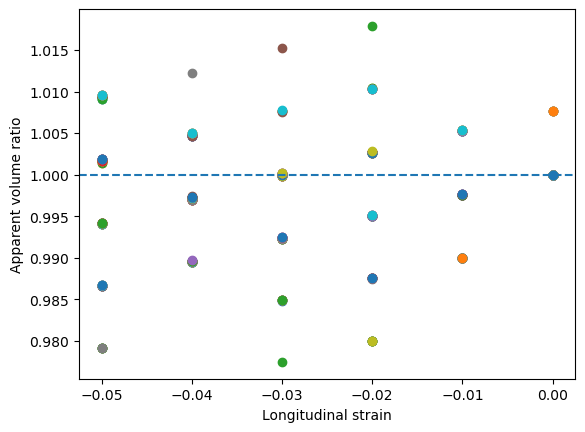

In [28]:
df["lambda_L"] = df["L"] / L0
df["lambda_T"] = df["D"] / T0s

df["volume_ratio"] = df["lambda_L"] * df["lambda_T"]**2

for line_id, g in df.groupby("line"):
    plt.plot(g["Lstrain"], g["volume_ratio"], marker="o", linestyle="", label=f"line {line_id}")

plt.axhline(1, linestyle="--")
plt.xlabel("Longitudinal strain")
plt.ylabel("Apparent volume ratio")
#plt.legend()
plt.show()

### Code to check threshold values

In [153]:
i = 0

vid_path = paths[i]
name = vid_path.with_suffix('').name
info_path = vid_path.parent / f'POC/{name}_info.json'

with open(info_path, 'r') as f:
    info = json.load(f)
    info['name'] = str(name)

f_before, f_after = info['t_before']*info['fps'], info['t_after']*info['fps'] # frame idx
f_interval = info['interval'] * info['fps'] # frames per jump

frames, ts = read_selected_frames(vid_path, [f_before, f_after])
frames = [frame[info['i1']:info['i2'], info['j1']:info['j2'], :] for frame in frames]
print(name)

V1_1


100


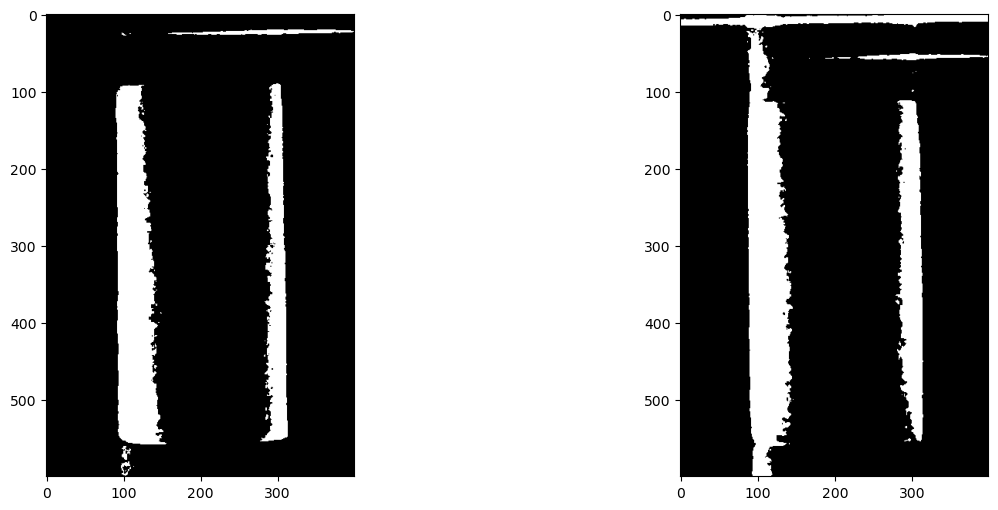

In [154]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

T = info['threshold']
print(T)
T = T
for i, ax_i in enumerate(ax):
    ax_i.imshow(np.where(frames[i][:, :, 2]<T, 0, 1), cmap='gray')
plt.show()

### Code to determine appropriate interval and nlines values
- based on image resolution

In [83]:
D = 10
L = 20

Dps = {}
Lps = {}
for vid_path in tqdm(paths):
    name = vid_path.with_suffix('').name
    csv_path = vid_path.parent / f'POC/{name}.csv'

    df = pd.read_csv(csv_path)

    Dps[name] = df[df['Lstrain']==0]['D'].mean()
    Lps[name] = df[df['Lstrain']==0]['L'].mean()

Dp_avg = np.mean([x for x in Dps.values()])
Lp_avg = np.mean([x for x in Lps.values()])
print(f'Average pixels accross diameter: {Dp_avg:.2f}')
print(f'  Average pixels accross length: {Lp_avg:.2f}')

img_res = np.mean([D / Dp_avg, L / Lp_avg])
print(f'\nAverage image resolution: {img_res:.4f} mm/pixel')

100%|██████████| 18/18 [00:00<00:00, 423.21it/s]

Average pixels accross diameter: 236.05
  Average pixels accross length: 482.72

Average image resolution: 0.0419 mm/pixel


In [88]:
# nlines covers central 50% of cylinder = 10 mm
nlines_range = L / 2
nlines_pixel_range = nlines_range / img_res
print(f'Pixels within central 50% of cylinder: {nlines_pixel_range:.2f}')

print('\nTherefore 101 nlines gives ~1 pixel spacing between each line')

Pixels within central 50% of cylinder: 238.68

Therefore 101 nlines gives ~1 pixel spacing between each line


In [ ]:
Lstrain_rate = 0.05/60 # /s

nu = 0.45
Tstrain_rate = nu * Lstrain_rate # /s
Dp_rate = (Tstrain_rate * D) / img_res # pixels/s

interval = 12 # s

print(
    f'If nu = {nu}, an interval of {interval} s ({Tstrain_rate*interval:.4f} strain) ' + 
    f'gives an increase of {Dp_rate * interval:.2f} pixels per inteval'
    )

If nu = 0.45, an interval of 12 s (0.0045 strain) gives an increase of 1.07 pixels per inteval


In [ ]:
# Relies on the number of lines cancelling out the noise due to the lack of resolution
# - ie some will have 1 pixel increase some 2 pixel increase some 0 pixel increase, and average over 101 nlines = 1 pixel increase

### Code to automate detecting contact

In [5]:
def compute_nu(info, toc, fps=30, strain_rate=0.05, nlines=101, interval=12, total_time=60):
    """strain_rate = 0.05 /min"""

    t_before = toc
    t_after = t_before + total_time
    bot_line = info['bot_line']
    span = info['span']
    Lp0 = info['Lp0']
    threshold = info['threshold']
    strain_jump = (strain_rate/60) * interval # interval in seconds

    f_before, f_after = t_before*fps, t_after*fps # frame idx
    f_interval = interval * fps # frames per jump
    frame_ids = np.arange(f_before, f_after+1, f_interval)

    frames, ts = read_selected_frames(vid_path, frame_ids)
    frames = [frame[info['i1']:info['i2'], info['j1']:info['j2'], 2]for frame in frames]

    results = []
    for i, (f, t) in enumerate(zip(frames, ts)):
        frame_id = (i*f_interval)+f_before
        mask = np.where(f<threshold, 0, 1)

        Lp = Lp0 - (i * Lp0 * strain_jump) 
        top_line = (bot_line[0]-Lp, bot_line[1]-Lp)
        lines_start = Lp / 4 # 5 mm (so central 10 mm)
        lines_gap = (Lp/2) / (nlines-1)

        for k in range(nlines):
            L_line = lines_start + lines_gap * k

            min_j, max_j = pixels_on_line(mask, bot_line, L_line, span)
            results.append({
                "frame": frame_id,
                "time": t,
                "line": k,
                "min_j": min_j,
                "max_j": max_j,
                "D": max_j-min_j, # Diameter in pixels
                "L": Lp, # Length in pixels
            })

    df = pd.DataFrame(results)
    # compute strains
    L0 = df['L'].max()
    T0s = df.groupby("line")["D"].transform("min")
    df['Lstrain'] = (df['L'] - L0) / L0
    df['Tstrain'] = (df["D"] - T0s) / T0s

    def poisson_from_origin_fit(g):
        g = g.replace([np.inf, -np.inf], np.nan)
        g = g.dropna(subset=["Lstrain", "Tstrain"])
        g = g[g["Lstrain"] != 0]

        x = g["Lstrain"].to_numpy()
        y = g["Tstrain"].to_numpy()

        slope = np.sum(x * y) / np.sum(x * x)

        return -slope

    poisson_by_line = df.groupby("line").apply(poisson_from_origin_fit)
    return poisson_by_line.mean() # == poisson_from_origin_fit(df) (cos they all have the same Lstrain)

In [113]:
nus = {}
for vid_path in tqdm(paths):
    name = vid_path.with_suffix('').name
    info_path = vid_path.parent / f'POC/{name}_info.json'

    with open(info_path, 'r') as f:
        info = json.load(f)
        info['name'] = str(name)

    nus[name] = compute_nu(info, info['toc'], interval=12, total_time=48)

100%|██████████| 18/18 [00:32<00:00,  1.78s/it]


In [114]:
nus # total_time = 48 (0->4.5%), interval = 12

{'V1_1': np.float64(0.6102495598109376),
 'V1_2': np.float64(0.4606132981365724),
 'V1_3': np.float64(0.45628155303631607),
 'V2_1': np.float64(0.5195806250971987),
 'V2_3': np.float64(0.46499323578688334),
 'V2_4': np.float64(0.5511457510477881),
 'V3_1': np.float64(0.4459956187712482),
 'V3_2': np.float64(0.4516939159919159),
 'V3_3': np.float64(0.4772640097965703),
 'H1_1': np.float64(0.4452342416906156),
 'H1_2': np.float64(0.3965298452920375),
 'H1_3': np.float64(0.5118332055427016),
 'H2_1': np.float64(0.4872209822123686),
 'H2_2': np.float64(0.464046107494406),
 'H2_3': np.float64(0.4554624510035465),
 'H3_1': np.float64(0.4283017437921278),
 'H3_2': np.float64(0.4527601302687588),
 'H3_3': np.float64(0.4459615534016703)}

In [ ]:
print(np.mean([x for x in nus.values()]), np.std([x for x in nus.values()]))
print(np.mean([y for x, y in nus.items() if 'V' in x]), np.std([y for x, y in nus.items() if 'V' in x]))
print(np.mean([y for x, y in nus.items() if 'H' in x]), np.std([y for x, y in nus.items() if 'H' in x]))

0.47362043489853684 0.04752818839240544
0.49309084083060345 0.05289359388641289
0.4541500289664704 0.031015023701236887
